# Modelo de dados da API — ER para o painel Macro

**Frente:** C — Dívida ativa × fatores macroeconômicos  
**Freeze:** `extracao_ref = 2026-03`  
**Objetivo:** responder, com evidência do `/meta` e dos schemas, **qual é a fact table**, quais são as entidades/satélites relacionados e **como as tabelas se juntam** no framing Macro (*estoque inscrito × arrecadação × macro externos*).

**Escopo deste notebook:** inventário + diagrama ER (Plotly + Mermaid/HTML + PNG Kaleido) + cardinalidades + padrões de `LEFT JOIN` para o painel mensal. Não estima cointegração aqui.

**Docs de frente:** `projects/macro/docs/C_divida_macro.md`, `README.md`, `CONTEXT.md`. Premissa de dump: `docs/api-dump/00_premissa_dump.md`.


## Definições (fact × dimensão × satélite)

Usamos o vocabulário de *dimensional modeling* (Kimball) e de *satellite* no sentido Data Vault / evento auxiliar — aplicados ao dump PGE, **não** a um warehouse corporativo completo.

| Papel | Definição operacional **neste** notebook | Exemplo no dump |
|-------|------------------------------------------|-----------------|
| **Fact (foto / estoque)** | Medida observada em um **grão temporal de extração**, com chave de negócio + chaves de tempo | `debito`: 1 linha = 1 `ID_DEBITO` × (`ANO_EXTRACAO`,`MES_EXTRACAO`) |
| **Fact (evento)** | Transação ou ocorrência datada, tipicamente N por dívida | `arrecadacao`: 1 linha ≈ 1 GARE (`ID_GARE_SEFAZ`) ligada a `ID_DEBITO` |
| **Satélite de status/evento** | Atributos ou eventos de cobrança ancorados em `ID_DEBITO`, grão ≠ foto mensal do estoque | `ajuizamento`, `protesto`, `parcelamento`, `receita` |
| **Entidade (nível CNPJ)** | Atributos do contribuinte, **não** do mesmo grão da dívida-foto | `faturamento` (`CNPJ` × `MES_ANO_REFERENCIA`) |
| **Dimensão degenerada / atributo** | Campos categóricos já embutidos na fact (sem tabela dimensão separada no dump) | `TIPO_DEBITO`, `SITUACAO_DEBITO` em `debito` |
| **Externo (fora do DB)** | Séries não presentes na API Inteligência Fiscal | BCB SGS (Selic, IPCA), IBGE (PIB), calendário REFIS |

**Tese Macro (a defender com o inventário abaixo):** a fact principal do painel de **estoque inscrito** é `debito` (grão dívida × foto mensal). `arrecadacao` é fact de **pagamento**. Demais tabelas são satélites em `ID_DEBITO`. `faturamento` é entidade em `CNPJ`. Macro BCB/IBGE ficam **fora** do dump.


## 0. Setup

Cliente compartilhado (`shared.cemepi_api`), freeze via `.env` (`EXTRACAO_ANO`/`EXTRACAO_MES`), token **nunca** impresso. Figuras estáticas em `projects/macro/output/figures/`.


In [22]:
from pathlib import Path
import sys, os, json, warnings
import numpy as np
import pandas as pd
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore", category=FutureWarning)

NB_DIR = Path.cwd()
MONO = next((p for p in [NB_DIR, *NB_DIR.parents] if (p / "shared" / "cemepi_api").exists()), NB_DIR)
sys.path.insert(0, str(MONO))
os.chdir(MONO)

from shared.cemepi_api import CemepiClient, load_settings

S = load_settings()
C = CemepiClient(S)
PROJ = MONO / "projects" / "macro"
FIG_DIR = PROJ / "output" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
LOCAL = PROJ / ".local"
LOCAL.mkdir(parents=True, exist_ok=True)
META_CACHE = LOCAL / "meta_tabelas_cache.json"

def save_fig(fig, stem: str, height: int = 560):
    fig.update_layout(height=height, template="plotly_white",
                      margin=dict(l=40, r=20, t=60, b=40))
    png = FIG_DIR / f"{stem}.png"
    html = LOCAL / "figures_html" / f"{stem}.html"
    html.parent.mkdir(parents=True, exist_ok=True)
    try:
        fig.write_image(str(png), scale=2)
        print("PNG", png)
    except Exception as e:
        print("write_image falhou:", e)
    fig.write_html(str(html), include_plotlyjs="cdn")
    fig.show()
    return png

assert (S.ano, S.mes) == (2026, 3), f"Freeze esperado 2026-03; got {S.ano}-{S.mes:02d}"
print("extracao", f"{S.ano:04d}-{S.mes:02d}", "| base", S.base)
print("token carregado:", "sim" if bool(S.token) else "NÃO")
print("FIG_DIR", FIG_DIR)


extracao 2026-03 | base http://143.107.158.76:8010
token carregado: sim
FIG_DIR /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/output/figures


## 1. Inventário `/meta/tabelas` + schemas

Consultamos a lista oficial de datasets e, para cada um, as colunas tipadas. Contagens `linhas` são **populacionais** reportadas pela API (não amostra). Para `debito`, a série histórica completa (~800 M) **não** é o grão do painel Macro: o painel filtra `ANO_EXTRACAO`/`MES_EXTRACAO` (foto ~8,8 M em 2026-03).


In [23]:
meta = C.get_json("/meta/tabelas")
META_CACHE.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")

rows = []
schemas = {}
for d in meta["datasets"]:
    name = d["dataset"]
    detail = C.get_json(f"/meta/tabelas/{name}")
    schemas[name] = detail
    cols = [c["nome"] for c in detail.get("colunas", [])]
    rows.append({
        "dataset": name,
        "tabela": detail.get("tabela"),
        "titulo": detail.get("titulo"),
        "linhas_api": detail.get("linhas"),
        "chave_meta": detail.get("chave"),
        "n_colunas": len(cols),
        "colunas": ", ".join(cols),
        "acelerado": detail.get("acelerado"),
    })

inv = pd.DataFrame(rows).sort_values("linhas_api", ascending=False).reset_index(drop=True)
inv.to_parquet(LOCAL / "inventario_datasets.parquet", index=False)
(LOCAL / "schemas_por_dataset.json").write_text(
    json.dumps(schemas, ensure_ascii=False, indent=2), encoding="utf-8"
)

extracoes = C.get_json("/v1/debito/extracoes").get("extracoes", [])
foto = next((e for e in extracoes if e.get("ano") == S.ano and e.get("mes") == S.mes), None)
print("foto 2026-03:", foto)
display(inv[["dataset", "tabela", "linhas_api", "chave_meta", "n_colunas", "titulo"]])


foto 2026-03: {'ano': 2026, 'mes': 3, 'qtd_debitos': 8821417, 'valor_sem_honorarios': 476012269972.2836, 'valor_honorarios': 65556541385.38969}


,dataset,tabela,linhas_api,chave_meta,n_colunas,titulo
0,debito,DEBITO,801844918,ID_DEBITO,16,Debitos inscritos (serie historica de extracoes)
1,faturamento,FATURAMENTO_MASCARADO,28337827,CNPJ,5,Faturamento mascarado por CNPJ
2,arrecadacao,ARRECADACAO,23199305,ID_DEBITO,14,Arrecadacao por GARE
3,protesto,STATUS_PROTESTO,18889381,ID_DEBITO,5,Status de protesto
4,receita,DEBITO_RECEITA,7754477,ID_DEBITO,18,Composicao da receita do debito
5,parcelamento,SOLICITACAOPARCELAMENTO,2715674,ID_DEBITO,11,Solicitacoes de parcelamento
6,ajuizamento,AJUIZAMENTO,1850991,ID_DEBITO,5,Ajuizamentos
7,ingest_rejects,_ingest_rejects,141837,NaN,8,Linhas recusadas na ingestao
8,ingest_log,_ingest_log,52,NaN,10,Log de ingestao


### Como ler o inventário

- **linhas_api**: população reportada por `/meta/tabelas/{dataset}` — use como ordem de grandeza, não como amostra do notebook.
- **chave_meta**: chave de negócio declarada pela API (`ID_DEBITO` na maioria; `CNPJ` em `faturamento`). Em `debito`, a chave **composta efetiva** do grão foto é `(ID_DEBITO, ANO_EXTRACAO, MES_EXTRACAO)` — a meta lista só `ID_DEBITO`.
- **Fora da lista / lacunas:** não há `garantia`; não há dívida **não inscrita**. Logs `_ingest_*` são metadados de carga, não fatos de pesquisa Macro.
- **Comparação:** `debito` (série) ≫ foto mensal ≫ `arrecadacao` ≫ satélites. Isso não implica 1:1 entre estoque e pagamento no mesmo mês.


In [24]:
samples = {}
for ds, extra in [
    ("debito", {"ANO_EXTRACAO": S.ano, "MES_EXTRACAO": S.mes}),
    ("arrecadacao", {"ANO": S.ano, "MES": S.mes}),
    ("faturamento", {}),
    ("ajuizamento", {}),
    ("protesto", {}),
    ("parcelamento", {}),
    ("receita", {}),
]:
    params = {"limit": 1, **extra}
    payload = C.get_json(f"/v1/data/{ds}", params=params)
    row = (payload.get("dados") or payload.get("data") or [None])[0]
    keys = list(row.keys()) if row else []
    samples[ds] = keys
    print(f"{ds:14s} n_cols={len(keys):2d} keys={keys}")

join_keys = {
    "debito": ["ID_DEBITO", "ANO_EXTRACAO", "MES_EXTRACAO", "CNPJ_DEVEDOR", "CDA_COMPLETA"],
    "arrecadacao": ["ID_DEBITO", "ANO", "MES", "ID_GARE_SEFAZ", "CDA_COMPLETA"],
    "faturamento": ["CNPJ", "MES_ANO_REFERENCIA"],
    "ajuizamento": ["ID_DEBITO", "PEF"],
    "protesto": ["ID_DEBITO"],
    "parcelamento": ["ID_DEBITO", "ID_SOLICITACAOPARCELAMENTO"],
    "receita": ["ID_DEBITO"],
}
display(pd.DataFrame([
    {"dataset": k, "chaves_relevantes": ", ".join(v)} for k, v in join_keys.items()
]))


debito         n_cols=16 keys=['ID_HT_EXTRACAO_REL_SGR', 'ANO_EXTRACAO', 'MES_EXTRACAO', 'ID_DEBITO', 'CDA_COMPLETA', 'DATA_INSCRICAO', 'SITUACAO_DEBITO', 'TIPO_DEBITO', 'STATUS_AJUIZAMENTO_DEBITO', 'VALOR_COM_VH', 'VALOR_SEM_HONORARIOS', 'VALOR_VH', 'HONORARIOS_ADMINISTRATIVOS', 'NOME_DEVEDOR', 'CNPJ_DEVEDOR', 'CPF_DEVEDOR']
arrecadacao    n_cols=14 keys=['ANO', 'MES', 'ID_DEBITO', 'CDA_COMPLETA', 'STATUS_AJUIZAMENTO_DEBITO', 'ID_GARE_SEFAZ', 'DATA_ARRECADACAO_GARE', 'VALOR_TOTAL_GARE', 'VALOR_RECEITA', 'JUROS_MORA', 'MULTA_MORA', 'VALOR_ACRESCIMO_FINANCEIRO', 'HONORARIOS_ADMINISTRATIVOS', 'HONORARIOS_ADVOCATICIOS']
faturamento    n_cols= 5 keys=['ID_FATURAMENTO', 'CNPJ', 'MES_ANO_REFERENCIA', 'VL_FATURAMENTO', 'DT_CONSULTA']
ajuizamento    n_cols= 5 keys=['ID_DEBITO', 'DT_INSCRICAO', 'PEF', 'DT_AJUIZAMENTO', 'NOMECOMARCA']
protesto       n_cols= 5 keys=['ID_DEBITO', 'DT_INSCRICAO', 'STATUS_PROTESTO', 'DATA_PROTESTO', 'VALOR_PROTESTADO']
parcelamento   n_cols=11 keys=['ID_SOLICITACAOP

,dataset,chaves_relevantes
0,debito,"ID_DEBITO, ANO_EXTRACAO, MES_EXTRACAO, CNPJ_DE..."
1,arrecadacao,"ID_DEBITO, ANO, MES, ID_GARE_SEFAZ, CDA_COMPLETA"
2,faturamento,"CNPJ, MES_ANO_REFERENCIA"
3,ajuizamento,"ID_DEBITO, PEF"
4,protesto,ID_DEBITO
5,parcelamento,"ID_DEBITO, ID_SOLICITACAOPARCELAMENTO"
6,receita,ID_DEBITO


## 2. Argumento: o que é fact no painel Macro

### 2.1 Fact primária — `debito` (estoque inscrito)

- **Grão:** dívida × foto mensal de extração = `(ID_DEBITO, ANO_EXTRACAO, MES_EXTRACAO)`.
- **Medidas típicas:** `VALOR_SEM_HONORARIOS`, `VALOR_VH`, flags de situação / `TIPO_DEBITO` / `STATUS_AJUIZAMENTO_DEBITO`.
- **Por que fact (não dimensão):** cada extração é um *snapshot* do estoque inscrito; a série temporal do painel B/C agrega essas fotos por mês (e opcionalmente por `TIPO_DEBITO`).
- **Cardinalidade temporal:** 1 dívida → N fotos ao longo de 2016-01 … 2026-03 (~119 extrações).

### 2.2 Fact de evento — `arrecadacao`

- **Grão:** pagamento GARE (chave prática `ID_GARE_SEFAZ`), ancorado em `ID_DEBITO`, com tempo próprio `(ANO, MES)` / `DATA_ARRECADACAO_GARE`.
- **Papel Macro:** Y de **fluxo** (arrecadação mensal), distinto do Y de **estoque**.
- **Join com estoque:** agregar GARE por mês (e opcionalmente por dívida) e alinhar ao calendário da foto — **não** assumir que `ANO`/`MES` da GARE ≡ `ANO_EXTRACAO`/`MES_EXTRACAO` sem checagem.

### 2.3 Satélites em `ID_DEBITO`

| Dataset | Papel | Cardinalidade típica |
|---------|-------|----------------------|
| `ajuizamento` | evento PEF / comarca | 1 `ID_DEBITO` → 0..N |
| `protesto` | status/valor protestado | 1 → 0..N |
| `parcelamento` | pedidos (REFIS/PPD/…) | 1 → 0..N pedidos |
| `receita` | composição do valor (principal, juros, multas) | 1 → 0..N (consulta) |

Úteis como **covariáveis / eventos** (H2–H4 REFIS via `parcelamento`), não como eixo principal estoque×macro.

### 2.4 Entidade — `faturamento`

- Chave `CNPJ` (meta) × `MES_ANO_REFERENCIA`.
- **Não** compartilha o grão `(ID_DEBITO, extração)`. Join: `debito.CNPJ_DEVEDOR = faturamento.CNPJ` após agregar dívidas por CNPJ/mês — proxy setorial **frágil** (valores mascarados; ver doc C).

### 2.5 Fora do DB

BCB/IBGE e calendário de eventos legais **não** entram pelo `/v1/data/*`. Entram no painel Macro por merge temporal externo (mês civil).


## 3. Diagrama ER (rede de relacionamentos)

### Como interpretar a figura seguinte

- **Nós:** tabelas (cor = papel: fact estoque, fact evento, satélite, entidade, externo).
- **Arestas:** chaves de junção candidatas (`ID_DEBITO`, `CNPJ`, alinhamento temporal mês).
- **Rótulo da aresta:** cardinalidade declarada (1:N etc.), **não** volume de linhas — volume está no inventário.
- **Caixa lógica (externos):** BCB/IBGE — sem FK na API; só alinhamento por mês do painel.
- **O que não overclaimar:** o grafo é modelo conceitual do dump de pesquisa; não prova integridade referencial 100% (órfãos possíveis) nem cobertura de dívida não inscrita.


In [25]:
nodes = {
    "debito": dict(papel="FACT estoque", chave="ID_DEBITO × ANO/MES_EXTRACAO", x=0.0, y=0.0),
    "arrecadacao": dict(papel="FACT evento", chave="ID_GARE_SEFAZ → ID_DEBITO", x=1.2, y=0.9),
    "ajuizamento": dict(papel="Satélite", chave="ID_DEBITO", x=-1.1, y=0.85),
    "protesto": dict(papel="Satélite", chave="ID_DEBITO", x=-1.3, y=-0.2),
    "parcelamento": dict(papel="Satélite", chave="ID_DEBITO", x=-0.9, y=-0.95),
    "receita": dict(papel="Satélite", chave="ID_DEBITO", x=0.2, y=-1.15),
    "faturamento": dict(papel="Entidade CNPJ", chave="CNPJ × MES_ANO", x=1.35, y=-0.55),
    "BCB_IBGE": dict(papel="EXTERNO", chave="mês civil (sem FK)", x=1.6, y=0.15),
}

color_map = {
    "FACT estoque": "#1f77b4",
    "FACT evento": "#ff7f0e",
    "Satélite": "#2ca02c",
    "Entidade CNPJ": "#9467bd",
    "EXTERNO": "#7f7f7f",
}

edges = [
    ("debito", "arrecadacao", "ID_DEBITO | 1:N GARE", "solid"),
    ("debito", "ajuizamento", "ID_DEBITO | 1:0..N", "solid"),
    ("debito", "protesto", "ID_DEBITO | 1:0..N", "solid"),
    ("debito", "parcelamento", "ID_DEBITO | 1:0..N", "solid"),
    ("debito", "receita", "ID_DEBITO | 1:0..N", "solid"),
    ("debito", "faturamento", "CNPJ_DEVEDOR=CNPJ (agregar)", "solid"),
    ("debito", "BCB_IBGE", "mês painel (sem FK)", "dash"),
    ("arrecadacao", "BCB_IBGE", "ANO/MES ↔ macro", "dash"),
]

edge_traces = []
for a, b, label, dash in edges:
    x0, y0 = nodes[a]["x"], nodes[a]["y"]
    x1, y1 = nodes[b]["x"], nodes[b]["y"]
    edge_traces.append(go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode="lines",
        line=dict(width=2, color="#555", dash=dash),
        hoverinfo="none",
        showlegend=False,
    ))
    edge_traces.append(go.Scatter(
        x=[(x0 + x1) / 2], y=[(y0 + y1) / 2],
        mode="text",
        text=[label],
        textfont=dict(size=9, color="#333"),
        hoverinfo="skip",
        showlegend=False,
    ))

node_traces = []
for papel, color in color_map.items():
    xs, ys, texts, hovers = [], [], [], []
    for name, n in nodes.items():
        if n["papel"] != papel:
            continue
        xs.append(n["x"]); ys.append(n["y"])
        texts.append(name)
        linhas = next((int(r["linhas_api"]) for _, r in inv.iterrows() if r["dataset"] == name), None)
        hovers.append(
            f"<b>{name}</b><br>papel={papel}<br>chave={n['chave']}"
            + (f"<br>linhas_api={linhas:,}" if linhas is not None else "<br>(fora da API)")
        )
    if not xs:
        continue
    node_traces.append(go.Scatter(
        x=xs, y=ys, mode="markers+text",
        text=texts, textposition="top center",
        marker=dict(size=28 if papel.startswith("FACT") else 22, color=color,
                    line=dict(width=2, color="white")),
        name=papel,
        hovertext=hovers, hoverinfo="text",
    ))

fig = go.Figure(data=edge_traces + node_traces)
fig.update_layout(
    title="ER conceitual — Inteligência Fiscal dump (Macro: estoque × arrecadação × externos)",
    xaxis=dict(visible=False, range=[-1.8, 2.0]),
    yaxis=dict(visible=False, range=[-1.5, 1.3]),
    legend=dict(orientation="h", yanchor="bottom", y=-0.12),
    annotations=[
        dict(x=1.55, y=0.45, text="externos (sem tabela na API)",
             showarrow=False, font=dict(size=10, color="#555")),
    ],
)
save_fig(fig, "macro_er_network_v0", height=620)


PNG /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/output/figures/macro_er_network_v0.png


PosixPath('/Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/output/figures/macro_er_network_v0.png')

### Diagrama Mermaid (complemento textual)

A figura Mermaid abaixo reforça a mesma topologia em notação ER clássica. Arestas `||--o{` = um para muitos opcional; externos em bloco separado (sem FK).


In [26]:
mermaid_body = """
erDiagram
    DEBITO ||--o{ ARRECADACAO : "ID_DEBITO"
    DEBITO ||--o{ AJUIZAMENTO : "ID_DEBITO"
    DEBITO ||--o{ STATUS_PROTESTO : "ID_DEBITO"
    DEBITO ||--o{ SOLICITACAOPARCELAMENTO : "ID_DEBITO"
    DEBITO ||--o{ DEBITO_RECEITA : "ID_DEBITO"
    DEBITO }o--|| FATURAMENTO_MASCARADO : "CNPJ_DEVEDOR=CNPJ"

    DEBITO {
        BIGINT ID_DEBITO PK
        BIGINT ANO_EXTRACAO PK
        BIGINT MES_EXTRACAO PK
        VARCHAR TIPO_DEBITO
        DOUBLE VALOR_SEM_HONORARIOS
        VARCHAR CNPJ_DEVEDOR FK
    }
    ARRECADACAO {
        BIGINT ID_GARE_SEFAZ PK
        BIGINT ID_DEBITO FK
        BIGINT ANO
        BIGINT MES
        DOUBLE VALOR_TOTAL_GARE
    }
    FATURAMENTO_MASCARADO {
        BIGINT ID_FATURAMENTO PK
        VARCHAR CNPJ FK
        VARCHAR MES_ANO_REFERENCIA
        DOUBLE VL_FATURAMENTO
    }
""".strip()

html_parts = [
    "<!DOCTYPE html><html><head><meta charset='utf-8'><title>Macro ER Mermaid</title>",
    "<script type='module'>",
    "  import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';",
    "  mermaid.initialize({ startOnLoad: true, theme: 'neutral' });",
    "</script>",
    "<style>body{font-family:system-ui,sans-serif;margin:1.5rem}",
    ".ext{border:2px dashed #888;padding:1rem;margin-top:1.5rem;border-radius:8px}",
    "code{background:#f4f4f4;padding:0.1rem 0.3rem}</style></head><body>",
    "<h1>ER Macro — dump Inteligência Fiscal</h1>",
    "<p>Freeze <code>extracao=2026-03</code>. Fact estoque: <b>debito</b>; fact evento: <b>arrecadacao</b>.</p>",
    "<pre class='mermaid'>\n",
    mermaid_body,
    "\n</pre>",
    "<div class='ext'><h2>Fora do DB (sem FK)</h2>",
    "<ul><li>BCB SGS — Selic, IPCA</li><li>IBGE — PIB / atividade</li>",
    "<li>Calendário REFIS / transação / Res. 9/2024</li></ul>",
    "<p>Merge apenas por <b>mês civil</b> do painel mensal.</p></div>",
    "<h2>Lacunas</h2><ul><li>Sem tabela <code>garantia</code></li>",
    "<li>Sem dívida <b>não inscrita</b></li></ul>",
    "</body></html>",
]
html = "".join(html_parts)
html_path = FIG_DIR / "macro_er_mermaid_v0.html"
html_path.write_text(html, encoding="utf-8")
(LOCAL / "figures_html").mkdir(parents=True, exist_ok=True)
(LOCAL / "figures_html" / "macro_er_mermaid_v0.html").write_text(html, encoding="utf-8")
print("Mermaid HTML:", html_path)

labels = [
    "debito (foto estoque)",
    "arrecadacao (GARE)",
    "satélites ID_DEBITO",
    "faturamento (CNPJ)",
    "painel mensal Macro",
    "BCB/IBGE (externo)",
]
sources = [0, 1, 2, 3, 0, 5]
targets = [4, 4, 4, 4, 3, 4]
values = [40, 25, 10, 8, 5, 20]
fig_s = go.Figure(go.Sankey(
    node=dict(
        label=labels, pad=18, thickness=18,
        color=["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#d62728", "#7f7f7f"],
    ),
    link=dict(
        source=sources, target=targets, value=values,
        label=["estoque→painel", "fluxo→painel", "eventos→painel",
               "proxy empresa", "CNPJ bridge", "macro X"],
    ),
))
fig_s.update_layout(
    title_text="Sankey conceitual — insumos do painel Macro (pesos ilustrativos, não volumes de join)"
)
save_fig(fig_s, "macro_er_sankey_painel_v0", height=480)


Mermaid HTML: /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/output/figures/macro_er_mermaid_v0.html
PNG /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/output/figures/macro_er_sankey_painel_v0.png


PosixPath('/Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/output/figures/macro_er_sankey_painel_v0.png')

### Como ler o Sankey

- **Eixo visual:** fluxos das fontes de dado para o nó **painel mensal Macro**.
- **Valores numéricos do Sankey são ilustrativos** (pesos de *papel analítico*), **não** contagens de linhas nem taxas de match — não usar como evidência empírica.
- Aresta `debito → faturamento` no ER é bridge por CNPJ; no Sankey o peso é baixo de propósito (proxy frágil).
- `BCB/IBGE` alimenta o painel sem passar pelas facts do dump.


## 4. Notas de cardinalidade (resumo operacional)

| Relação | Cardinalidade | Comentário Macro |
|---------|---------------|------------------|
| dívida → fotos em `debito` | **1 → N** | N = nº de extrações em que a CDA ainda aparece (~até 119) |
| `ID_DEBITO` → GARE (`arrecadacao`) | **1 → 0..N** | muitos débitos sem pagamento no dump; outros com várias GARE |
| `ID_DEBITO` → `ajuizamento` | **1 → 0..N** | PEF/comarca; nem todo estoque está ajuizado |
| `ID_DEBITO` → `protesto` | **1 → 0..N** | status pode repetir / histórico |
| `ID_DEBITO` → `parcelamento` | **1 → 0..N** | vários pedidos (rompidos/pagos) por dívida |
| `ID_DEBITO` → `receita` | **1 → 0..N** | composição contábil do valor |
| `CNPJ` → `faturamento` | **1 → N** meses | depois agrega-se / alinha-se ao mês do painel |
| foto mensal ↔ série BCB | **1 → 1** por mês | merge externo; sem FK |

**Implicação para joins:** partir de uma **foto** `debito` filtrada (`ANO_EXTRACAO`,`MES_EXTRACAO`) e fazer `LEFT JOIN` / agregações — inner join puro em GARE **enviesa** para quem pagou.


## 5. Padrões de `LEFT JOIN` para o painel Macro

Exemplo didático (SQL lógico / DuckDB sobre Parquet local). Agrega arrecadação no mês civil e ancora no estoque da foto — alinhamento típico do Plano B reutilizado pela frente C.

```sql
-- Foto de estoque (fact primária)
WITH estoque AS (
  SELECT
    ID_DEBITO,
    ANO_EXTRACAO AS ano,
    MES_EXTRACAO AS mes,
    TIPO_DEBITO,
    SITUACAO_DEBITO,
    CNPJ_DEVEDOR,
    VALOR_SEM_HONORARIOS
  FROM debito
  WHERE ANO_EXTRACAO = 2026 AND MES_EXTRACAO = 3
),
-- Fact de pagamento agregada ao mês (exemplo: mesmo mês civil da foto)
gare_mes AS (
  SELECT
    ID_DEBITO,
    ANO AS ano,
    MES AS mes,
    SUM(VALOR_TOTAL_GARE) AS arrec_mes,
    COUNT(*) AS n_gare
  FROM arrecadacao
  WHERE ANO = 2026 AND MES = 3
  GROUP BY 1, 2, 3
)
SELECT
  e.ano, e.mes, e.TIPO_DEBITO,
  COUNT(*) AS n_debitos,
  SUM(e.VALOR_SEM_HONORARIOS) AS estoque_valor,
  SUM(COALESCE(g.arrec_mes, 0)) AS arrec_valor,
  SUM(COALESCE(g.n_gare, 0)) AS n_gare
FROM estoque e
LEFT JOIN gare_mes g
  ON e.ID_DEBITO = g.ID_DEBITO
 AND e.ano = g.ano
 AND e.mes = g.mes
GROUP BY 1, 2, 3;
```

**Variante painel longitudinal:** repetir o CTE `estoque` para cada `(ANO_EXTRACAO, MES_EXTRACAO)`, agregar GARE por `(ANO, MES)` independente, e só então `LEFT JOIN` séries BCB/IBGE em `(ano, mes)`.

**CNPJ / faturamento (opcional):**

```sql
LEFT JOIN faturamento f
  ON f.CNPJ = e.CNPJ_DEVEDOR
 AND f.MES_ANO_REFERENCIA = printf('%04d-%02d', e.ano, e.mes)  -- ajustar formato real
```

Conferir o formato de `MES_ANO_REFERENCIA` na amostra antes de produção.


In [27]:
fat = C.sample_dataset("faturamento", limit=5, select="MES_ANO_REFERENCIA,VL_FATURAMENTO")
print("faturamento sample cols:", list(fat.columns))
print("MES_ANO_REFERENCIA exemplos:", fat["MES_ANO_REFERENCIA"].astype(str).head(5).tolist())

rel = pd.DataFrame([
    {"from": "debito", "to": "arrecadacao", "on": "ID_DEBITO", "card": "1:0..N", "tipo": "fact→fact evento"},
    {"from": "debito", "to": "ajuizamento", "on": "ID_DEBITO", "card": "1:0..N", "tipo": "fact→satélite"},
    {"from": "debito", "to": "protesto", "on": "ID_DEBITO", "card": "1:0..N", "tipo": "fact→satélite"},
    {"from": "debito", "to": "parcelamento", "on": "ID_DEBITO", "card": "1:0..N", "tipo": "fact→satélite"},
    {"from": "debito", "to": "receita", "on": "ID_DEBITO", "card": "1:0..N", "tipo": "fact→satélite"},
    {"from": "debito", "to": "faturamento", "on": "CNPJ_DEVEDOR=CNPJ", "card": "N:N via agregação", "tipo": "fact→entidade"},
    {"from": "debito/arrecadacao", "to": "BCB/IBGE", "on": "ano-mês civil", "card": "1:1 mês", "tipo": "externo"},
])
rel.to_parquet(LOCAL / "relacionamentos_macro_v0.parquet", index=False)
rel.to_csv(FIG_DIR / "macro_er_relationships_v0.csv", index=False)
display(rel)


faturamento sample cols: ['MES_ANO_REFERENCIA', 'VL_FATURAMENTO']
MES_ANO_REFERENCIA exemplos: ['2023-05-01T00:00:00', '2023-05-01T00:00:00', '2023-05-01T00:00:00', '2023-05-01T00:00:00', '2023-05-01T00:00:00']


,from,to,on,card,tipo
0,debito,arrecadacao,ID_DEBITO,1:0..N,fact→fact evento
1,debito,ajuizamento,ID_DEBITO,1:0..N,fact→satélite
2,debito,protesto,ID_DEBITO,1:0..N,fact→satélite
3,debito,parcelamento,ID_DEBITO,1:0..N,fact→satélite
4,debito,receita,ID_DEBITO,1:0..N,fact→satélite
5,debito,faturamento,CNPJ_DEVEDOR=CNPJ,N:N via agregação,fact→entidade
6,debito/arrecadacao,BCB/IBGE,ano-mês civil,1:1 mês,externo


## 6. O que está FORA do DB + lacunas

### Externos (caixa tracejada)
- **BCB SGS:** Selic, IPCA (e correlatas) — controles / co-movimento.
- **IBGE:** PIB / atividade — se a hipótese H1 exigir.
- **Calendário manual:** REFIS, transação, Res. 9/2024 — dummies de evento (H2–H4); `parcelamento` pode *auxiliar* mas não substitui o calendário legal.

### Lacunas estruturais (declarar no paper)
1. **Sem `garantia`** — confirmado pela lista `/meta/tabelas` (mesmo achado da frente D).
2. **Sem dívida não inscrita** — o framing correto é **estoque inscrito**, não inadimplência corrente.
3. Tipagem frágil em alguns campos (`VALOR_COM_VH` / datas como string em `debito`) — sanitizar no painel B antes do macro.


In [28]:
names = [d["dataset"] for d in meta["datasets"]]
print("garantia na lista?", "garantia" in names)
r = C.session.get(f"{C.s.base}/v1/data/garantia", params={"limit": 1}, timeout=30)
print("GET /v1/data/garantia ->", r.status_code, (r.text[:180] or "").replace(C.s.token, "***"))

inv_plot = inv[~inv["dataset"].astype(str).str.startswith("ingest")].copy()
inv_plot["papel"] = inv_plot["dataset"].map({
    "debito": "FACT estoque",
    "arrecadacao": "FACT evento",
    "faturamento": "Entidade CNPJ",
    "ajuizamento": "Satélite",
    "protesto": "Satélite",
    "parcelamento": "Satélite",
    "receita": "Satélite",
}).fillna("outro")
fig_b = px.bar(
    inv_plot.sort_values("linhas_api"),
    x="linhas_api", y="dataset", color="papel", orientation="h",
    title="Ordem de grandeza populacional (API) — log-x",
    log_x=True,
    color_discrete_map=color_map,
)
fig_b.update_layout(xaxis_title="linhas_api (log)", yaxis_title="")
save_fig(fig_b, "macro_er_inventory_bars_v0", height=420)

if foto:
    print(
        f"debito série={int(inv.loc[inv.dataset=='debito','linhas_api'].iloc[0]):,} | "
        f"foto {S.ano}-{S.mes:02d} qtd_debitos={foto['qtd_debitos']:,}"
    )


garantia na lista? False
GET /v1/data/garantia -> 404 {"erro":"nao_encontrado","mensagem":"dataset desconhecido: 'garantia'","detalhe":{"datasets":["ajuizamento","arrecadacao","debito","faturamento","ingest_log","ingest_rejects","parc
PNG /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/output/figures/macro_er_inventory_bars_v0.png


debito série=801,844,918 | foto 2026-03 qtd_debitos=8,821,417


### Como ler o gráfico de barras

- **Eixo X (log):** número de linhas reportado pela API; escala log porque `debito` (série) domina.
- **Comparação justa:** para estoque Macro, contrastar mentalmente a **foto** (~8,8 M em 2026-03) com `arrecadacao` (~23 M eventos), não a série completa de `debito` (~802 M).
- **Cores = papel analítico** atribuído neste notebook (tese da seção 2), não um campo da API.


## 7. TLDR

1. **Fact estoque (Macro):** `debito`, grão `(ID_DEBITO, ANO_EXTRACAO, MES_EXTRACAO)`.  
2. **Fact pagamento:** `arrecadacao` (GARE), 1 dívida → 0..N.  
3. **Satélites:** `ajuizamento`, `protesto`, `parcelamento`, `receita` via `ID_DEBITO`.  
4. **Entidade:** `faturamento` via `CNPJ` — outro grão.  
5. **Externos:** BCB/IBGE + calendário REFIS — fora da API.  
6. **Join padrão:** foto `debito` `LEFT JOIN` GARE agregada; depois merge temporal macro.  
7. **Lacunas:** sem garantia; sem não-inscrita.  
8. **Figuras:** `output/figures/macro_er_network_v0.png`, `macro_er_sankey_painel_v0.png`, `macro_er_inventory_bars_v0.png`, `macro_er_mermaid_v0.html`.


## Head / describe / frequências categóricas

Para cada tabela do modelo Macro/API: **head(15)**, **describe** (numéricos da amostra) e **frequências populacionais** das categóricas via `/v1/data/{dataset}/aggregate?group_by=…&metrics=count&order_by=qtd_linhas` (até 5000 níveis; barras = top 40).

- `debito`: freeze **2026-03** (`/distinct` estoura 60s na série histórica)
- PII mascarado no head
- `HONORARIOS_*` e `REGRA_PARCELAMENTO` truncados em 5000 (quase-contínuos / alta cardinalidade)
- `receita`: categórica útil = `ID_SITUACAO`; `faturamento`: sem categórica (só CNPJ/datas/valores)
- Artefatos: `projects/macro/output/eda_head_describe/` · `output/figures/macro_freq_*`


In [29]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT_CAND = [
    Path("projects/macro/output/eda_head_describe"),
    Path("../../output/eda_head_describe"),
    Path("/Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/output/eda_head_describe"),
]
OUT = next(p for p in ROOT_CAND if p.exists())
meta = json.loads((OUT / "_meta.json").read_text(encoding="utf-8"))
TABLES = ["debito", "arrecadacao", "ajuizamento", "protesto", "parcelamento", "receita", "faturamento"]
print("OUT", OUT)
for k in TABLES:
    cats = meta[k].get("categoricals") or {}
    print(k, {c: cats[c].get("n_distinct") for c in cats})


OUT projects/macro/output/eda_head_describe
debito {'HONORARIOS_ADMINISTRATIVOS': 5000, 'SITUACAO_DEBITO': 5, 'STATUS_AJUIZAMENTO_DEBITO': 3, 'TIPO_DEBITO': 44}
arrecadacao {'HONORARIOS_ADMINISTRATIVOS': 5000, 'HONORARIOS_ADVOCATICIOS': 5000, 'STATUS_AJUIZAMENTO_DEBITO': 3}
ajuizamento {'NOMECOMARCA': 372}
protesto {'STATUS_PROTESTO': 22}
parcelamento {'REGRA_PARCELAMENTO': 5000, 'STATUS_PARCELAMENTO': 7, 'TIPO_PARCELAMENTO': 18, 'VIGENCIA_PARCELAMENTO': 16}
receita {'ID_SITUACAO': 5}
faturamento {}


---## `debito`

Colunas (16): `ID_HT_EXTRACAO_REL_SGR`, `ANO_EXTRACAO`, `MES_EXTRACAO`, `ID_DEBITO`, `CDA_COMPLETA`, `DATA_INSCRICAO`, `SITUACAO_DEBITO`, `TIPO_DEBITO`, `STATUS_AJUIZAMENTO_DEBITO`, `VALOR_COM_VH`, `VALOR_SEM_HONORARIOS`, `VALOR_VH`, `HONORARIOS_ADMINISTRATIVOS`, `NOME_DEVEDOR`, `CNPJ_DEVEDOR`, `CPF_DEVEDOR`

PII mascarado no head: `NOME_DEVEDOR`, `CNPJ_DEVEDOR`, `CPF_DEVEDOR`

### head(15)

,ID_HT_EXTRACAO_REL_SGR,ANO_EXTRACAO,MES_EXTRACAO,ID_DEBITO,CDA_COMPLETA,DATA_INSCRICAO,SITUACAO_DEBITO,TIPO_DEBITO,STATUS_AJUIZAMENTO_DEBITO,VALOR_COM_VH,VALOR_SEM_HONORARIOS,VALOR_VH,HONORARIOS_ADMINISTRATIVOS,NOME_DEVEDOR,CNPJ_DEVEDOR,CPF_DEVEDOR
0,66609,2026,3,73697978,1457630895,2025-12-12 00:00:00.0,Inscrito,ICMS Declarado,Liberado para ajuizamento,31.20,28.36,0.00,2.84,[hash_f263173a45],[hash_580faf357c],NaN
1,66609,2026,3,66225140,1373235826,2023-07-27 00:00:00.0,Inscrito,IPVA,Liberado para ajuizamento,437.14,397.40,0.00,39.74,[hash_7cc782c9b3],NaN,[hash_4962ee7b93]
2,66609,2026,3,41138903,1137094204,2014-02-24 00:00:00.0,Inscrito,ICMS Declarado,Ajuizado,20343.89,16953.24,3390.65,0.00,[hash_ed903f2466],[hash_4bf385c956],NaN
3,66609,2026,3,60315163,1308917155,2021-08-18 00:00:00.0,Inscrito,IPVA,Liberado para ajuizamento,752.73,684.30,0.00,68.43,[hash_d0ec050427],NaN,[hash_b1819759d3]
4,66609,2026,3,65292642,1363173783,2023-07-24 00:00:00.0,Inscrito,IPVA,Liberado para ajuizamento,2478.07,2252.79,0.00,225.28,[hash_a50bcf11e5],NaN,[hash_83cc1c0586]
5,66609,2026,3,25506601,1000517630,2008-08-18 00:00:00.0,Inscrito,ICMS Declarado,Ajuizado,486.19,405.16,81.03,0.00,[hash_2a488757ce],[hash_51ffc213ec],NaN
6,66609,2026,3,72570947,1444559325,2025-11-05 00:00:00.0,Inscrito,IPVA,Liberado para ajuizamento,2026.55,1842.32,0.00,184.23,[hash_cb30673f98],NaN,[hash_425b0b9dad]
7,66609,2026,3,73870223,1459549480,2025-12-24 00:00:00.0,Inscrito,IPVA,Liberado para ajuizamento,1359.63,1236.03,0.00,123.60,[hash_9829f7cf90],NaN,[hash_c8b4495ec0]
8,66609,2026,3,70079236,1416276862,2024-12-28 00:00:00.0,Inscrito,IPVA,Liberado para ajuizamento,1473.03,1339.12,0.00,133.91,[hash_39f7c5172e],NaN,[hash_d8d3e1506e]
9,66609,2026,3,66341257,1374437469,2023-08-30 00:00:00.0,Inscrito,ICMS Declarado,Liberado para ajuizamento,6393.45,5812.23,0.00,581.22,[hash_01fe44c17b],[hash_8aa9c42205],NaN


### describe (numéricos da amostra head)

,count,mean,std,min,25%,50%,75%,max
ID_HT_EXTRACAO_REL_SGR,15.0,6.660900e+04,0.000000e+00,66609.00,6.660900e+04,66609.00,66609.00,66609.00
ANO_EXTRACAO,15.0,2.026000e+03,0.000000e+00,2026.00,2.026000e+03,2026.00,2026.00,2026.00
MES_EXTRACAO,15.0,3.000000e+00,0.000000e+00,3.00,3.000000e+00,3.00,3.00,3.00
ID_DEBITO,15.0,6.140811e+07,1.508895e+07,25506601.00,6.144230e+07,66225140.00,72370403.50,73870223.00
VALOR_COM_VH,15.0,3.854491e+03,6.472480e+03,31.20,4.616650e+02,1359.63,2395.04,20343.89
VALOR_SEM_HONORARIOS,15.0,3.306757e+03,5.387083e+03,28.36,4.012800e+02,1236.03,2177.31,16953.24
VALOR_VH,15.0,4.341173e+02,1.131317e+03,0.00,0.000000e+00,0.00,0.00,3390.65
HONORARIOS_ADMINISTRATIVOS,15.0,1.136167e+02,1.519310e+02,0.00,5.505000e+00,68.43,159.07,581.22


### Categóricas — frequências · 4 colunas

#### `debito.HONORARIOS_ADMINISTRATIVOS` — 5000 distintos, n=6,482,771 (lista truncada em 5000) — _quase-contínuo (VARCHAR monetário); lista truncada em 5000_

,value,count
0,0.00,2163658
1,10.06,15352
2,10.70,14968
3,11.55,14020
4,10.88,12847
...,...,...
95,101.74,4328
96,7.58,4328
97,93.26,4328
98,23.82,4318


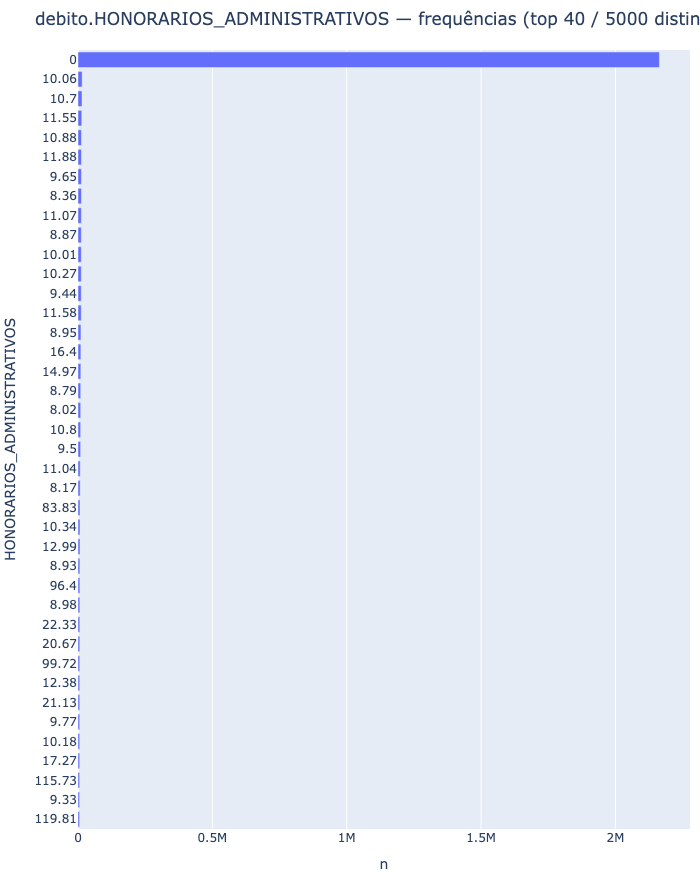

#### `debito.SITUACAO_DEBITO` — 5 distintos, n=8,821,417

,value,count
0,Inscrito,8759186
1,Suspenso,47721
2,Processo sobrestado - artigo 40 (por decisao j...,12655
3,Selecionado para Saneamento,1439
4,Suspenso outros motivos ( por decisao judicial...,416


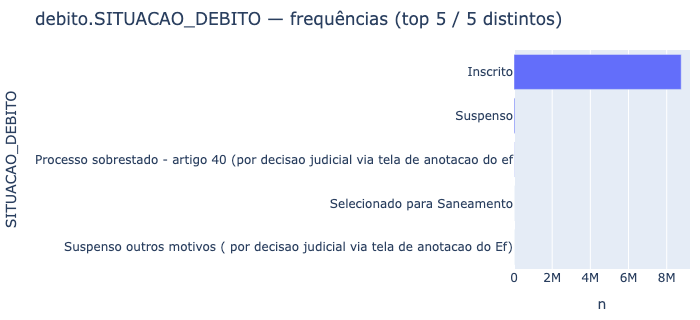

#### `debito.STATUS_AJUIZAMENTO_DEBITO` — 3 distintos, n=8,821,417

,value,count
0,Liberado para ajuizamento,6680823
1,Ajuizado,2140588
2,Aguardando liberação para ajuizar,6


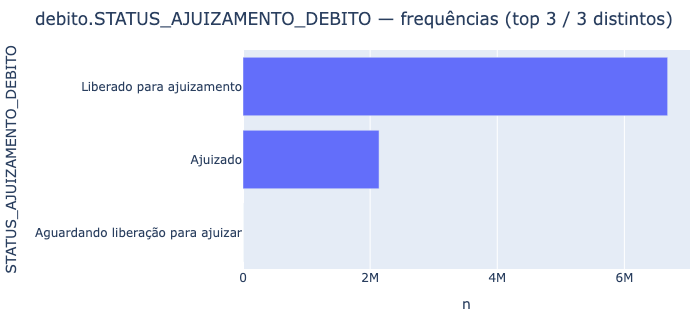

#### `debito.TIPO_DEBITO` — 44 distintos, n=8,821,417

,value,count
0,IPVA,5702184
1,ICMS Declarado,2284655
2,Taxa Judiciária,616276
3,ICMS Autuação,59964
4,Multa Penal,56610
5,Multas,50736
6,ICMS Fecoep,7920
7,Multa de Nota Fiscal Paulista,7828
8,Multa Ipca,6844
9,Multa CBPMESP,6755


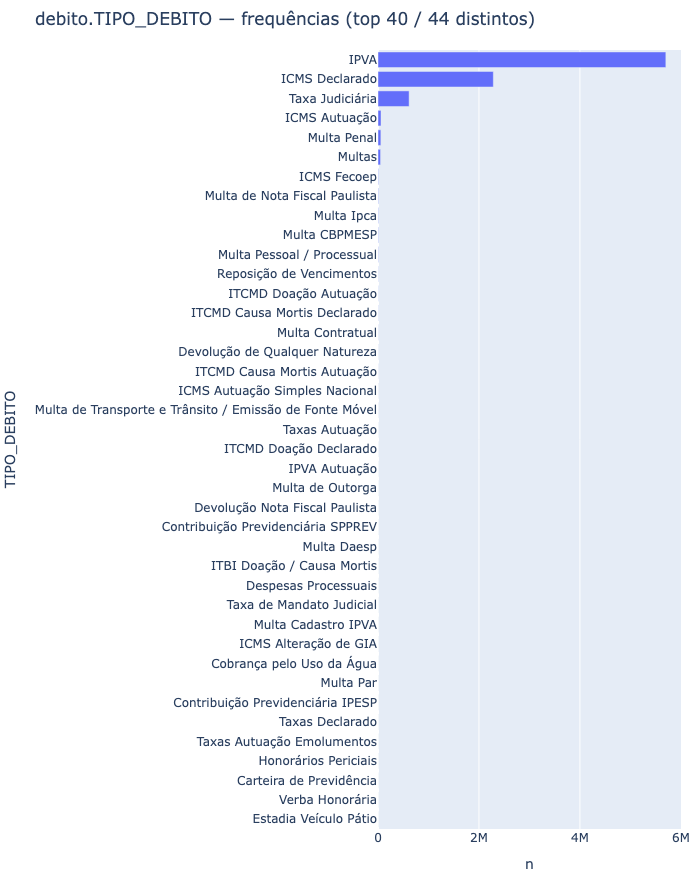

---## `arrecadacao`

Colunas (14): `ANO`, `MES`, `ID_DEBITO`, `CDA_COMPLETA`, `STATUS_AJUIZAMENTO_DEBITO`, `ID_GARE_SEFAZ`, `DATA_ARRECADACAO_GARE`, `VALOR_TOTAL_GARE`, `VALOR_RECEITA`, `JUROS_MORA`, `MULTA_MORA`, `VALOR_ACRESCIMO_FINANCEIRO`, `HONORARIOS_ADMINISTRATIVOS`, `HONORARIOS_ADVOCATICIOS`

### head(15)

,ANO,MES,ID_DEBITO,CDA_COMPLETA,STATUS_AJUIZAMENTO_DEBITO,ID_GARE_SEFAZ,DATA_ARRECADACAO_GARE,VALOR_TOTAL_GARE,VALOR_RECEITA,JUROS_MORA,MULTA_MORA,VALOR_ACRESCIMO_FINANCEIRO,HONORARIOS_ADMINISTRATIVOS,HONORARIOS_ADVOCATICIOS
0,2016,12,37424942,1100565437,Ajuizado,36793012,2016-12-09T00:00:00,96.85,61.00,5.53,6.10,19.61,NaN,4.611820
1,2016,12,41833522,1141300125,Liberado para ajuizamento,36807978,2016-12-12T00:00:00,668.79,435.78,29.69,37.87,165.45,NaN,0.000000
2,2016,12,26777067,1008199468,Ajuizado,36823448,2016-12-14T00:00:00,41.66,19.36,10.32,1.94,8.07,NaN,1.976140
3,2016,12,41857786,1141542764,Liberado para ajuizamento,36806856,2016-12-12T00:00:00,8.74,4.51,2.02,0.33,1.71,NaN,0.166620
4,2016,12,1138762,669353120,Ajuizado,36877626,2016-12-23T00:00:00,236.43,80.92,89.55,8.09,46.61,NaN,11.258731
5,2016,12,44926533,1163595844,Liberado para ajuizamento,36826174,2016-12-09T00:00:00,77.41,49.63,10.17,4.96,12.65,NaN,0.000000
6,2016,12,26296977,1005213011,Ajuizado,36805027,2016-12-12T00:00:00,44.56,11.19,10.46,6.02,14.77,NaN,2.122440
7,2016,12,1111693,455323783,Ajuizado,36795532,2016-12-09T00:00:00,3.32,1.06,1.11,0.11,0.88,NaN,0.158125
8,2016,12,25983617,1002445464,Ajuizado,36803321,2016-12-12T00:00:00,1939.97,431.45,819.99,119.33,476.82,NaN,92.380000
9,2016,12,35502245,1094982179,Ajuizado,36792762,2016-12-09T00:00:00,18.88,8.20,5.65,0.73,3.94,NaN,0.365154


### describe (numéricos da amostra head)

,count,mean,std,min,25%,50%,75%,max
ANO,15.0,2.016000e+03,0.000000e+00,2016.00,2.016000e+03,2.016000e+03,2.016000e+03,2016.00
MES,15.0,1.200000e+01,0.000000e+00,12.00,1.200000e+01,1.200000e+01,1.200000e+01,12.00
ID_DEBITO,15.0,3.029815e+07,1.338750e+07,1111693.00,2.651972e+07,3.529006e+07,3.962923e+07,44926533.00
ID_GARE_SEFAZ,15.0,3.680553e+07,2.474260e+04,36770853.00,3.679368e+07,3.680332e+07,3.680742e+07,36877626.00
VALOR_TOTAL_GARE,15.0,3.044380e+02,5.274416e+02,3.32,3.027000e+01,8.507000e+01,2.728650e+02,1939.97
VALOR_RECEITA,15.0,1.236227e+02,1.853746e+02,1.06,9.695000e+00,4.191000e+01,9.773000e+01,551.72
JUROS_MORA,15.0,7.542267e+01,2.076214e+02,1.11,5.590000e+00,1.046000e+01,3.876000e+01,819.99
MULTA_MORA,15.0,1.672067e+01,3.150999e+01,0.11,1.335000e+00,4.960000e+00,9.770000e+00,119.33
VALOR_ACRESCIMO_FINANCEIRO,15.0,7.813133e+01,1.343925e+02,0.88,6.005000e+00,1.961000e+01,7.457500e+01,476.82
HONORARIOS_ADVOCATICIOS,15.0,1.054119e+01,2.358977e+01,0.00,2.186425e-01,2.122440e+00,7.935276e+00,92.38


### Categóricas — frequências · 3 colunas

#### `arrecadacao.HONORARIOS_ADMINISTRATIVOS` — 5000 distintos, n=21,184,181 (lista truncada em 5000) — _quase-contínuo (VARCHAR monetário); lista truncada em 5000_

,value,count
0,NaN,19405608
1,0.00,17805
2,18.03,5222
3,18.21,4985
4,18.39,4087
...,...,...
95,16.92,949
96,17.91,946
97,17.23,940
98,16.96,939


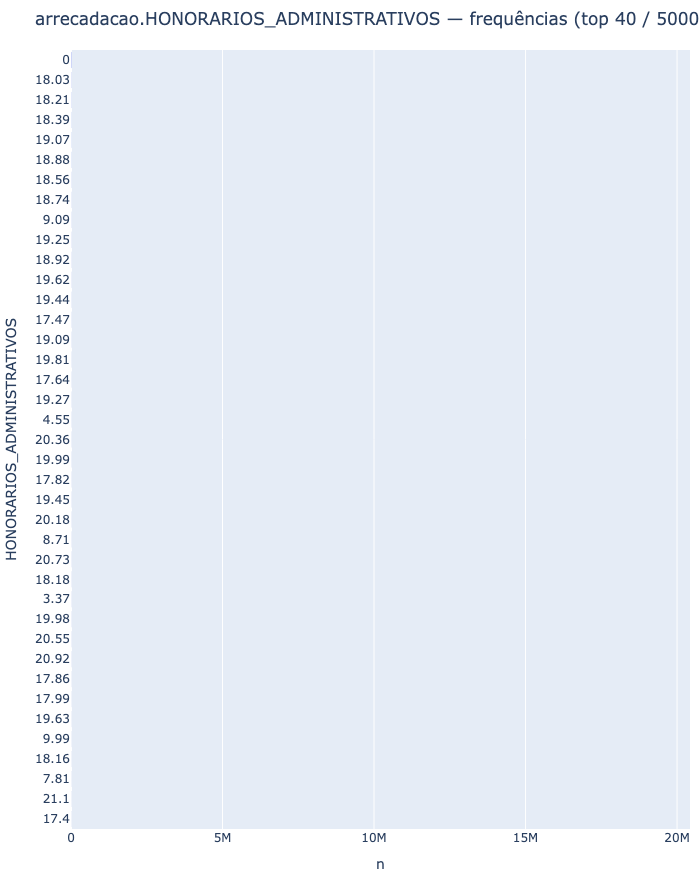

#### `arrecadacao.HONORARIOS_ADVOCATICIOS` — 5000 distintos, n=16,871,853 (lista truncada em 5000) — _quase-contínuo (VARCHAR monetário); lista truncada em 5000_

,value,count
0,NaN,9513536
1,0.00,6820072
2,5.00,2527
3,4.99,2201
4,16.66,1685
...,...,...
95,53.73,206
96,220.41,206
97,54.16,205
98,24.06,204


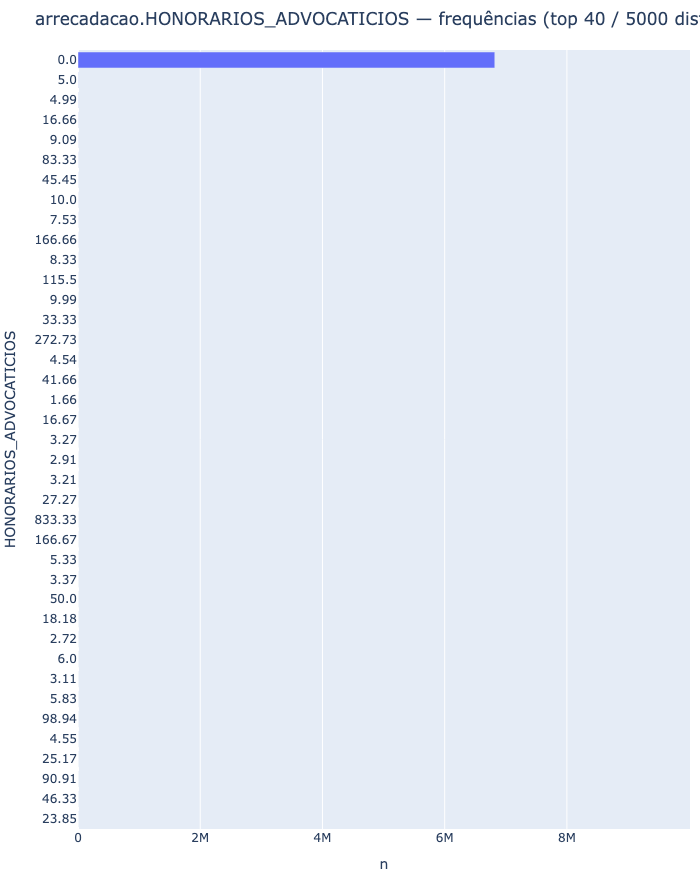

#### `arrecadacao.STATUS_AJUIZAMENTO_DEBITO` — 3 distintos, n=23,199,305

,value,count
0,Liberado para ajuizamento,16882882
1,Ajuizado,6316297
2,Aguardando liberação para ajuizar,126


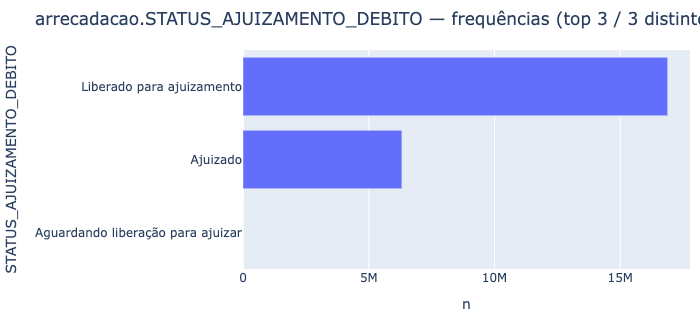

---## `ajuizamento`

Colunas (5): `ID_DEBITO`, `DT_INSCRICAO`, `PEF`, `DT_AJUIZAMENTO`, `NOMECOMARCA`

### head(15)

,ID_DEBITO,DT_INSCRICAO,PEF,DT_AJUIZAMENTO,NOMECOMARCA
0,49534713,2016-01-04,1500047-12.2016.8.26.0236,2016-10-17,Comarca de Ibitinga
1,49534721,2016-01-04,1500004-47.2017.8.26.0040,2017-03-20,Comarca de Américo Brasiliense
2,49534754,2016-01-04,1500034-38.2016.8.26.0066,2016-10-19,Comarca de Barretos
3,49534787,2016-01-04,1507794-97.2016.8.26.0014,2016-10-14,Vara das Execuções Fiscais Estaduais da Comarc...
4,49534797,2016-01-04,1630083-81.2016.8.26.0224,2016-05-16,Comarca de Guarulhos
5,49534834,2016-01-04,1512966-43.2016.8.26.0071,2016-10-15,Comarca de Bauru
6,49534861,2016-01-04,1500644-22.2017.8.26.0114,2017-04-01,Comarca de Campinas
7,49534892,2016-01-04,1507013-75.2016.8.26.0014,2016-10-14,Vara das Execuções Fiscais Estaduais da Comarc...
8,49534901,2016-01-04,1507221-59.2016.8.26.0014,2016-10-14,Vara das Execuções Fiscais Estaduais da Comarc...
9,49534924,2016-01-04,1526343-06.2017.8.26.0602,2017-10-25,Comarca de Sorocaba


### describe (numéricos da amostra head)

,count,mean,std,min,25%,50%,75%,max
ID_DEBITO,15.0,4.953486e+07,85.095297,49534713.0,49534792.0,49534892.0,49534935.5,49534947.0


### Categóricas — frequências · 1 colunas

#### `ajuizamento.NOMECOMARCA` — 372 distintos, n=1,850,991

,value,count
0,Comarca de São Paulo - Foro das Execuções Fisc...,528272
1,Vara das Execuções Fiscais Estaduais da Comarc...,412475
2,Comarca de Guarulhos,57290
3,Comarca de Barueri,48037
4,Comarca de SÃ£o Paulo - Foro das ExecuÃ§Ãµes F...,47637
...,...,...
95,Comarca de Itapeva,1846
96,Comarca de Capivari,1727
97,Comarca de Jaguariúna,1712
98,Comarca de Nova Odessa,1709


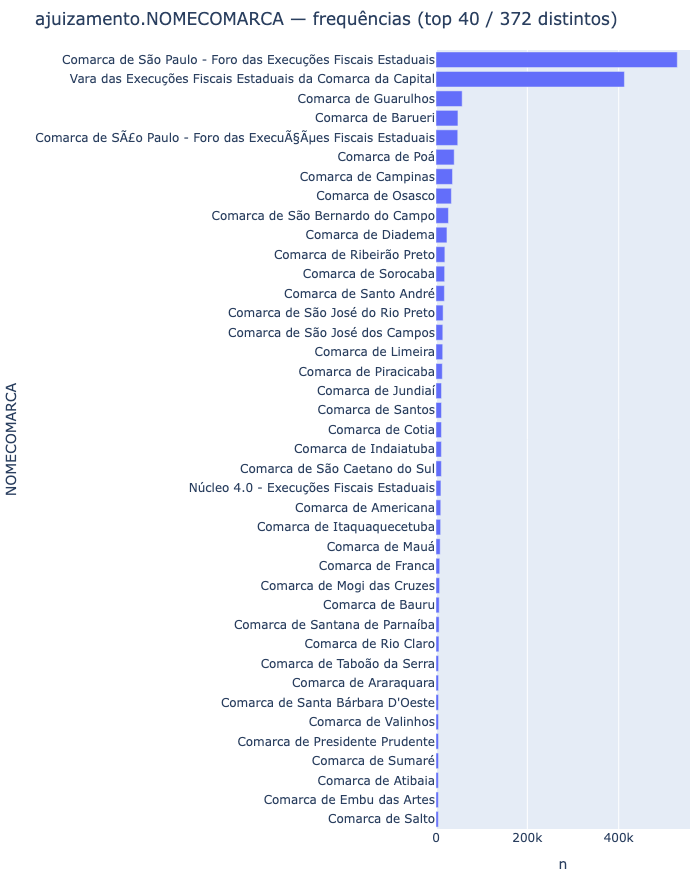

---## `protesto`

Colunas (5): `ID_DEBITO`, `DT_INSCRICAO`, `STATUS_PROTESTO`, `DATA_PROTESTO`, `VALOR_PROTESTADO`

### head(15)

,ID_DEBITO,DT_INSCRICAO,STATUS_PROTESTO,DATA_PROTESTO,VALOR_PROTESTADO
0,49834147,2016-02-02,Aguardando pagamento dos emolumentos e cancela...,2016-03-22,600.52
1,50775145,2016-09-06,Aguardando pagamento dos emolumentos e cancela...,2016-10-13,727.84
2,49925101,2016-02-03,Aguardando pagamento dos emolumentos e cancela...,2016-03-23,715.78
3,63661520,2022-12-01,Pago Cartório,NaN,307.83
4,57096736,2020-04-23,Aguardando pagamento dos emolumentos e cancela...,2020-07-16,474946.14
5,67621828,2024-05-07,Cartório nao protestou,NaN,198.37
6,49858815,2016-02-02,Aguardando pagamento dos emolumentos e cancela...,2019-06-18,1097.80
7,50936882,2016-09-12,Aguardando pagamento dos emolumentos e cancela...,2016-10-11,967.70
8,52075325,2017-02-21,Pago Cartório,2017-06-05,11424.32
9,55866374,2019-05-09,Protesto Cancelado,2019-06-11,895.79


### describe (numéricos da amostra head)

,count,mean,std,min,25%,50%,75%,max
ID_DEBITO,15.0,5.522770e+07,5.889786e+06,49834147.00,5.048895e+07,52678201.00,5.709495e+07,67621828.00
VALOR_PROTESTADO,15.0,3.302672e+04,1.222848e+05,198.37,5.503350e+02,773.11,9.766350e+02,474946.14


### Categóricas — frequências · 1 colunas

#### `protesto.STATUS_PROTESTO` — 22 distintos, n=18,889,381

,value,count
0,Aguardando pagamento dos emolumentos e cancela...,6485125
1,Cartório protestou,5674265
2,Protesto Cancelado,2270004
3,Pago Cartório,1504413
4,Cartório nao protestou,1374504
5,Aguardando geração do arquivo,708353
6,Débito protestado quitado via IEPTB-SP,283067
7,Aguardando seleção para próxima remessa de pro...,270509
8,Solicitado Cancelamento,215931
9,Enviado para cartório de protesto,51821


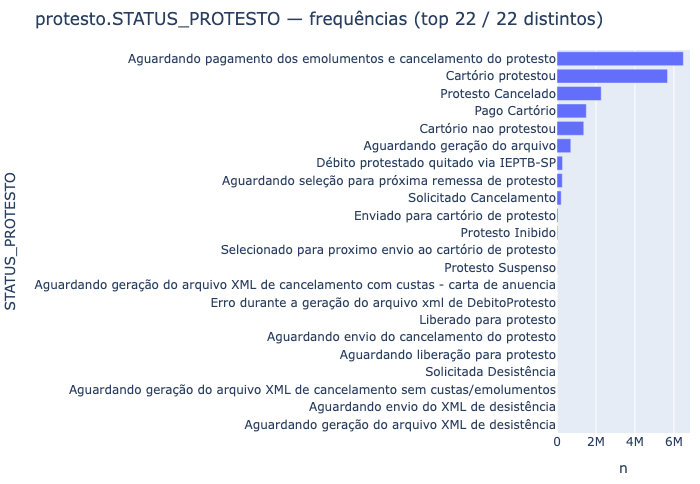

---## `parcelamento`

Colunas (11): `ID_SOLICITACAOPARCELAMENTO`, `DATA_SOLICITACAO`, `STATUS_PARCELAMENTO`, `DATA_ROMPIMENTO`, `QTD_PARCELAS`, `TIPO_PARCELAMENTO`, `VIGENCIA_PARCELAMENTO`, `REGRA_PARCELAMENTO`, `ID_DEBITO`, `DT_INSCRICAO`, `DT_CONSULTA`

### head(15)

,ID_SOLICITACAOPARCELAMENTO,DATA_SOLICITACAO,STATUS_PARCELAMENTO,DATA_ROMPIMENTO,QTD_PARCELAS,TIPO_PARCELAMENTO,VIGENCIA_PARCELAMENTO,REGRA_PARCELAMENTO,ID_DEBITO,DT_INSCRICAO,DT_CONSULTA
0,50057290,2022-02-17,Rompido pelo contribuinte,2022-11-29,18,ICMS Resolução SF/PGE- 01,ICMS_SF_01,Regra Geral ICMS Resolução SF/PGE- 01 2018,60570931,2021-08-24,2026-04-27
1,50051587,2021-10-27,Não celebrado,NaN,60,ICMS Resolução SF/PGE- 01,ICMS_SF_01,Regra Geral ICMS Resolução SF/PGE- 01 2018,60570931,2021-08-24,2026-04-27
2,50049465,2021-09-21,Não celebrado,NaN,24,ICMS Resolução SF/PGE- 01,ICMS_SF_01,Regra Geral ICMS Resolução SF/PGE- 01 2018,60570935,2021-08-24,2026-04-27
3,50128242,2025-07-03,Não celebrado,NaN,11,ICMS Resolução SF/PGE- 01,ICMS_SF_01,Regra Geral ICMS Resolução SF/PGE- 01 2018,60570964,2021-08-24,2026-04-27
4,50071065,2022-12-07,Em andamento,NaN,60,ICMS Resolução SF/PGE- 01,ICMS_SF_01,Regra Geral ICMS Resolução SF/PGE- 01 2018,60570979,2021-08-24,2026-04-27
5,70105216,2024-04-18,Rompido pelo contribuinte,2026-01-29,119,PARCELAMENTO TRANSAÇÃO INDIVIDUAL,ARTIGO_43,Regra Específica - EDITAL PGE/TR N.º 1/2024 pa...,60570988,2021-08-24,2026-04-27
6,50071065,2022-12-07,Em andamento,NaN,60,ICMS Resolução SF/PGE- 01,ICMS_SF_01,Regra Geral ICMS Resolução SF/PGE- 01 2018,60570992,2021-08-24,2026-04-27
7,50050116,2021-10-05,Rompido pela PGE,2024-04-25,60,ICMS Resolução SF/PGE- 01,ICMS_SF_01,Regra Geral ICMS Resolução SF/PGE- 01 2018,60570999,2021-08-24,2026-04-27
8,70107679,2024-04-25,Em andamento,NaN,59,PARCELAMENTO TRANSAÇÃO INDIVIDUAL,ARTIGO_43,Regra Específica - EDITAL PGE/TR N.º 1/2024 pa...,60570999,2021-08-24,2026-04-27
9,50054133,2021-12-17,Rompido pelo contribuinte,2022-11-29,18,ICMS Resolução SF/PGE- 01,ICMS_SF_01,Regra Geral ICMS Resolução SF/PGE- 01 2018,60571012,2021-08-24,2026-04-27


### describe (numéricos da amostra head)

,count,mean,std,min,25%,50%,75%,max
ID_SOLICITACAOPARCELAMENTO,15.0,5.407912e+07,8.294330e+06,50049465.0,50055711.5,50071065.0,50125715.5,70107679.0
QTD_PARCELAS,15.0,4.880000e+01,2.667315e+01,11.0,30.5,59.0,60.0,119.0
ID_DEBITO,15.0,6.057099e+07,3.284567e+01,60570931.0,60570971.5,60570999.0,60571012.0,60571029.0


### Categóricas — frequências · 4 colunas

#### `parcelamento.REGRA_PARCELAMENTO` — 5000 distintos, n=2,708,706 (lista truncada em 5000) — _alta cardinalidade; lista truncada em 5000_

,value,count
0,Regra Geral ICMS Resolução SF/PGE- 01 2018,677695
1,Regra Geral PPD,370269
2,Regra Geral IPVA Resolução 26/2023,319614
3,Regra Geral PEP,283543
4,Regra Geral IPVA Resolução 22/2020,219118
...,...,...
95,Regra Específica - EDITAL PGE/TR N.º 1/2024 pa...,165
96,Regra Específica - EDITAL PGE/TR N.º 1/2024 pa...,164
97,Regra Geral de ITCMD - Doação - (Autuação) - P...,164
98,USINA SANTA ROSA LTDA - ICMS,164


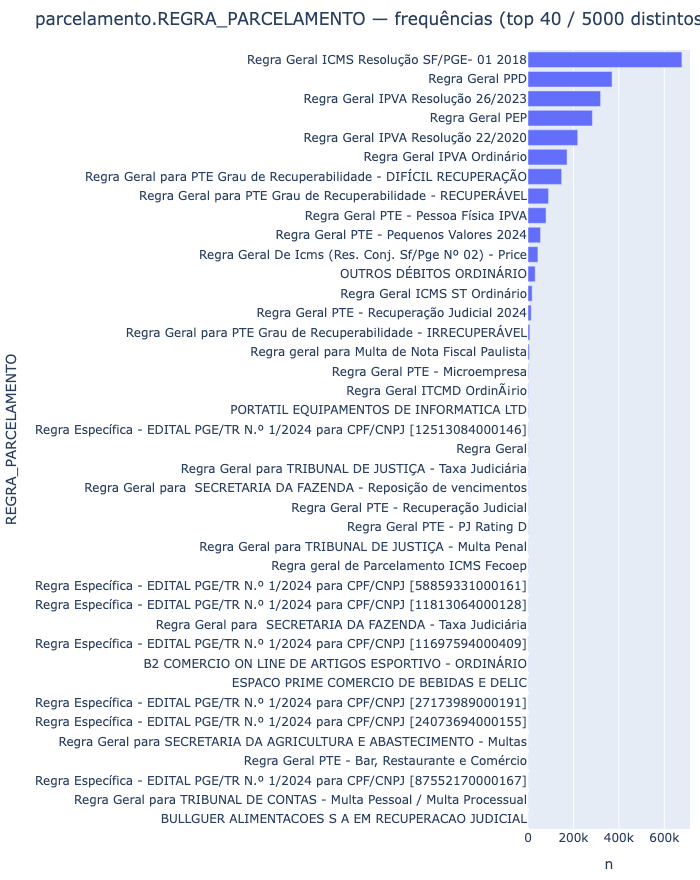

#### `parcelamento.STATUS_PARCELAMENTO` — 7 distintos, n=2,715,674

,value,count
0,Pago,846775
1,Rompido pelo contribuinte,707031
2,Não celebrado,650717
3,Em andamento,384417
4,Rompido pela PGE,113031
5,Aguardando celebração,13698
6,Rompido por falha do sistema. Aberta nova poss...,5


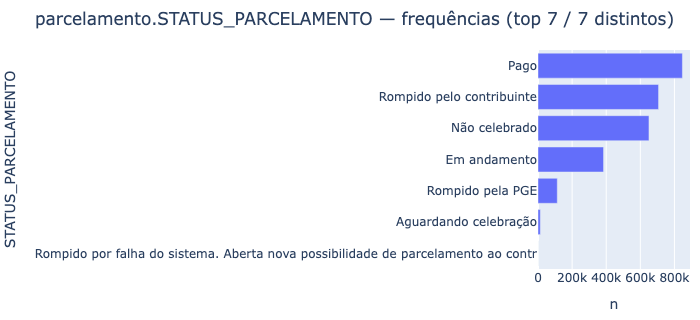

#### `parcelamento.TIPO_PARCELAMENTO` — 18 distintos, n=2,715,674

,value,count
0,ICMS Resolução SF/PGE- 01,681107
1,PPD,370269
2,IPVA Resolução 26/2023,319614
3,PEP,283543
4,PTE GRAU DE RECUPERABILIDADE,246860
5,IPVA Resolução 22/2020,219118
6,IPVA ORDINÁRIO,172094
7,PARCELAMENTO TRANSAÇÃO INDIVIDUAL,157902
8,PARCELAMENTO DE TRANSAÇÃO POR EDITAL,84201
9,PTE PEQUENOS VALORES,55239


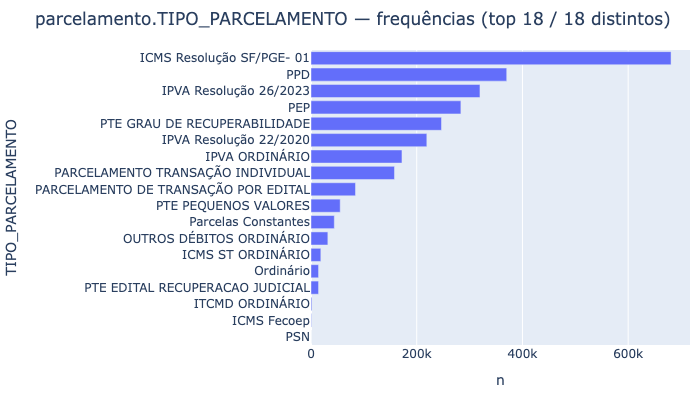

#### `parcelamento.VIGENCIA_PARCELAMENTO` — 16 distintos, n=2,715,674

,value,count
0,NaN,802885
1,ICMS_SF_01,681111
2,PPD_2017,367148
3,EDITAL_25,246860
4,ARTIGO_43,147764
5,PEP_5,137446
6,PEP_4,132366
7,PTE,94339
8,EDITAL_24,55239
9,REC_JUD_24,14282


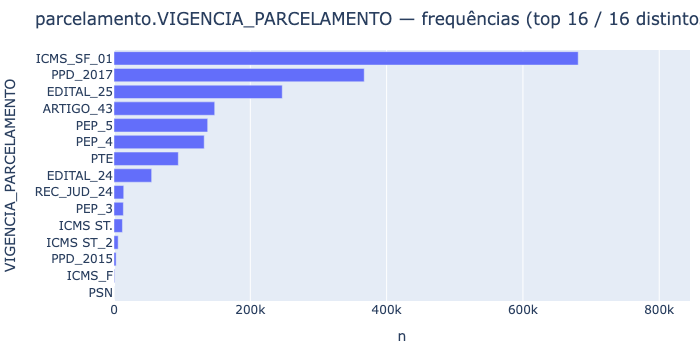

---## `receita`

Colunas (18): `ID_DEBITO`, `DT_INSCRICAO`, `DT_CONSULTA`, `ID_SITUACAO`, `VL_PRINCIPAL`, `VL_CORRECAO`, `VL_JUROS_MORA_PRINCIPAL`, `VL_MULTA_MORA_PRINCIPAL`, `VL_MULTA_PUNITIVA`, `VL_CORRECAO_MONETARIA_MULTA_PUNITIVA`, `VL_JUROS_MORA_MULTA_PUNITIVA`, `VL_CUSTAS_JUDICIAIS`, `VL_DESPESAS_PROCESSUAIS`, `VL_JUROS_VINCENDOS`, `VL_ACRESCIMO_FINANCEIRO`, `VL_MULTA_MORATORIA`, `VL_MULTA_POR_ATRASO`, `VL_JUROS_MORA_MULTA_MORA`

### head(15)

,ID_DEBITO,DT_INSCRICAO,DT_CONSULTA,ID_SITUACAO,VL_PRINCIPAL,VL_CORRECAO,VL_JUROS_MORA_PRINCIPAL,VL_MULTA_MORA_PRINCIPAL,VL_MULTA_PUNITIVA,VL_CORRECAO_MONETARIA_MULTA_PUNITIVA,VL_JUROS_MORA_MULTA_PUNITIVA,VL_CUSTAS_JUDICIAIS,VL_DESPESAS_PROCESSUAIS,VL_JUROS_VINCENDOS,VL_ACRESCIMO_FINANCEIRO,VL_MULTA_MORATORIA,VL_MULTA_POR_ATRASO,VL_JUROS_MORA_MULTA_MORA
0,63532547,2022-11-08,2026-04-27,1,776.41,156.64,457.20,0.00,0.0,0,0.0,0,0,0,0,0.0,0.0,0.00
1,73652446,2025-12-09,2026-04-27,1,134.51,0.00,77.11,26.90,0.0,0,0.0,0,0,0,0,0.0,0.0,0.00
2,63531435,2022-11-06,2026-04-27,1,159.85,32.25,90.29,0.00,0.0,0,0.0,0,0,0,0,0.0,0.0,0.00
3,63564051,2022-11-10,2026-04-27,1,624.12,0.00,412.29,124.82,0.0,0,0.0,0,0,0,0,0.0,0.0,82.46
4,63564225,2022-11-10,2026-04-27,1,439.64,0.00,252.05,87.93,0.0,0,0.0,0,0,0,0,0.0,0.0,50.41
5,63564032,2022-11-10,2026-04-27,1,708.64,0.00,468.13,141.73,0.0,0,0.0,0,0,0,0,0.0,0.0,93.63
6,73604227,2025-11-27,2026-04-27,1,176.80,6.69,11.01,0.00,0.0,0,0.0,0,0,0,0,0.0,0.0,0.00
7,63463536,2022-10-29,2026-04-27,1,3197.00,645.00,1690.48,0.00,0.0,0,0.0,0,0,0,0,0.0,0.0,0.00
8,73604164,2025-11-27,2026-04-27,1,185.10,7.00,13.45,0.00,0.0,0,0.0,0,0,0,0,0.0,0.0,0.00
9,73631137,2025-11-28,2026-04-27,1,185.10,7.00,15.37,0.00,0.0,0,0.0,0,0,0,0,0.0,0.0,0.00


### describe (numéricos da amostra head)

,count,mean,std,min,25%,50%,75%,max
ID_DEBITO,15.0,6.641923e+07,4.508026e+06,63463536.00,63548289.50,64262590.00,6.895641e+07,73652446.00
ID_SITUACAO,15.0,1.000000e+00,0.000000e+00,1.00,1.00,1.00,1.000000e+00,1.00
VL_PRINCIPAL,15.0,6.486067e+02,7.555207e+02,134.51,180.95,624.12,7.502800e+02,3197.00
VL_CORRECAO,15.0,5.912200e+01,1.669801e+02,0.00,0.00,0.00,1.962500e+01,645.00
VL_JUROS_MORA_PRINCIPAL,15.0,3.463693e+02,4.134954e+02,11.01,83.70,390.23,4.114850e+02,1690.48
VL_MULTA_MORA_PRINCIPAL,15.0,6.518667e+01,7.038162e+01,0.00,0.00,26.90,1.430500e+02,151.94
VL_MULTA_PUNITIVA,15.0,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.000000e+00,0.00
VL_CORRECAO_MONETARIA_MULTA_PUNITIVA,15.0,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.000000e+00,0.00
VL_JUROS_MORA_MULTA_PUNITIVA,15.0,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.000000e+00,0.00
VL_CUSTAS_JUDICIAIS,15.0,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.000000e+00,0.00


### Categóricas — frequências · 1 colunas

#### `receita.ID_SITUACAO` — 5 distintos, n=7,754,477

,value,count
0,1,7722674
1,6,30936
2,7,515
3,8,311
4,10,41


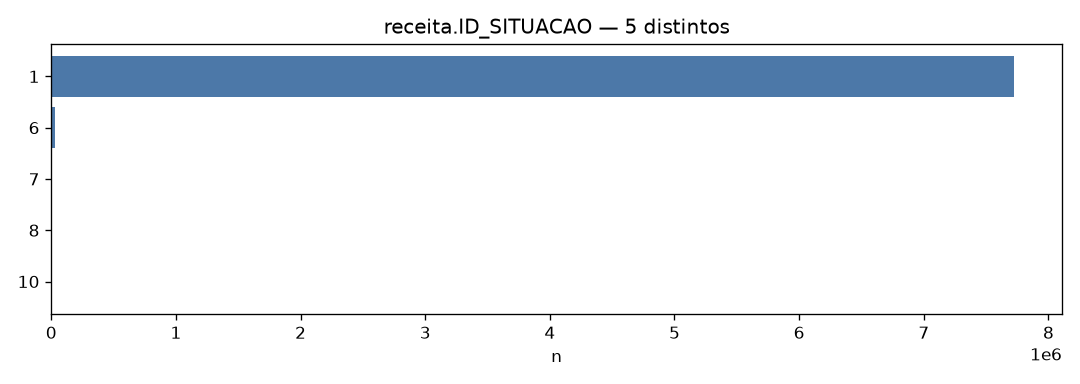

---## `faturamento`

Colunas (5): `ID_FATURAMENTO`, `CNPJ`, `MES_ANO_REFERENCIA`, `VL_FATURAMENTO`, `DT_CONSULTA`

PII mascarado no head: `CNPJ`

### head(15)

,ID_FATURAMENTO,CNPJ,MES_ANO_REFERENCIA,VL_FATURAMENTO,DT_CONSULTA
0,144177674,[hash_cd04c4ad25],2023-05-01T00:00:00,0.0,2023-07-13
1,144177675,[hash_eac080b3d1],2023-05-01T00:00:00,42000.0,2023-07-13
2,144177676,[hash_b8629ed8be],2023-05-01T00:00:00,0.0,2023-07-13
3,144177677,[hash_0c2ad47594],2023-05-01T00:00:00,3000000.0,2023-07-13
4,144177678,[hash_ac8c08c7db],2023-05-01T00:00:00,0.0,2023-07-13
5,144177679,[hash_8824e35d78],2023-05-01T00:00:00,0.0,2023-07-13
6,144177680,[hash_998bb84111],2023-05-01T00:00:00,0.0,2023-07-13
7,144177681,[hash_8bec767a0e],2023-05-01T00:00:00,0.0,2023-07-13
8,144177682,[hash_b5e2e0895d],2023-05-01T00:00:00,0.0,2023-07-13
9,144177683,[hash_cac9185dfa],2023-05-01T00:00:00,0.0,2023-07-13


### describe (numéricos da amostra head)

,count,mean,std,min,25%,50%,75%,max
ID_FATURAMENTO,15.0,1.441777e+08,4.472136e+00,144177674.0,144177677.5,144177681.0,144177684.5,144177688.0
VL_FATURAMENTO,15.0,8.869467e+06,3.351864e+07,0.0,0.0,0.0,0.0,130000000.0


### Categóricas — frequências · 0 colunas

_Nenhuma categórica (só IDs/PII/datas/valores)._

In [31]:
for name in TABLES:
    info = meta[name]
    display(Markdown(f"---## `{name}`"))
    display(Markdown("Colunas (" + str(len(info.get('columns') or [])) + "): " + ", ".join(f"`{c}`" for c in (info.get('columns') or []))))
    if info.get("masked"):
        display(Markdown("PII mascarado no head: " + ", ".join(f"`{c}`" for c in info["masked"])))

    display(Markdown("### head(15)"))
    display(pd.read_csv(OUT / f"{name}_head15.csv"))

    display(Markdown("### describe (numéricos da amostra head)"))
    desc_path = OUT / f"{name}_describe.csv"
    if desc_path.exists() and desc_path.stat().st_size > 5:
        desc = pd.read_csv(desc_path, index_col=0)
        display(desc if len(desc) else Markdown("_Sem colunas numéricas na amostra._"))
    else:
        display(Markdown("_Sem describe._"))

    cats = info.get("categoricals") or {}
    display(Markdown(f"### Categóricas — frequências · {len(cats)} colunas"))
    if not cats:
        display(Markdown("_Nenhuma categórica (só IDs/PII/datas/valores)._"))
    for col, cf in cats.items():
        if "error" in cf:
            display(Markdown(f"**`{col}`**: falha — `{cf['error']}`"))
            continue
        freq = pd.read_csv(cf["path"])
        trunc = " (lista truncada em 5000)" if cf.get("truncated") else ""
        note = f" — _{cf['note']}_" if cf.get("note") else ""
        tot = cf.get("total_n")
        tot_s = f", n={tot:,}" if tot is not None else ""
        display(Markdown(f"#### `{name}.{col}` — {cf['n_distinct']} distintos{tot_s}{trunc}{note}"))
        display(freq.head(100) if len(freq) > 100 else freq)
        png = Path(cf["png"]) if cf.get("png") else None
        if png and png.exists():
            display(Image(filename=str(png)))
        elif cf.get("html") and Path(cf["html"]).exists():
            display(Markdown(f"[HTML]({cf['html']})"))


<!-- END_HEAD_SECTION -->